# LiveWeatherCast v2 — Decomposition Quality Analysis (Rainfall)

This notebook adds decomposition quality analysis and rank sweep to the rainfall forecasting pipeline.

**Key insight**: Forecasting accuracy depends entirely on decomposition quality. If the tensor can be reconstructed with minimal error, forecasting works well. If reconstruction is error-prone, forecasting collapses.

In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorly.decomposition import parafac
from tensorly import cp_to_tensor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error
from statsmodels.tsa.ar_model import AutoReg

In [64]:
PERIOD = 47  # total years
TRAIN_YEARS = 42
TEST_YEARS = 5
TIME = 12    # months
FEATURES = 29  # stations
print(f"Tensor dimensions: {PERIOD} x {TIME} x {FEATURES}")

Tensor dimensions: 47 x 12 x 29


## 1. Data Collection & Preprocessing

In [65]:
CSV_PATH = 'all_stations_monthly_data.csv'
df_raw = pd.read_csv(CSV_PATH)

# Drop unnamed index column and Time column
df_raw = df_raw.drop(columns=[df_raw.columns[0], 'Time'], errors='ignore')
df_raw.columns = [c.strip() for c in df_raw.columns]

# Remove duplicate year-month rows
df_raw = df_raw.drop_duplicates(subset=['Year', 'Month'], keep='first').reset_index(drop=True)

# Select stations with good coverage (< 20% NaN, >= 30 years of data)
station_cols = [c for c in df_raw.columns if c not in ['Year', 'Month']]
nan_counts = df_raw[station_cols].isna().sum().sort_values(ascending=True)
max_nan = int(len(df_raw) * 0.20)
good_stations = nan_counts[nan_counts <= max_nan].index.tolist()

min_months = 360
final_stations = [s for s in good_stations if df_raw[s].dropna().shape[0] >= min_months]
FEATURES = len(final_stations)

# Fill remaining NaN with 0 (dry months)
df_clean = df_raw[['Year', 'Month'] + final_stations].copy()
df_clean[final_stations] = df_clean[final_stations].fillna(0)

feature_names = final_stations
print(f"Data shape: {df_clean.shape}")
print(f"Stations ({FEATURES}): {feature_names}")
df_clean.head()

Data shape: (564, 31)
Stations (29): ['Barisal', 'CoxsBazar', 'Ishurdi', 'Faridpur', 'Satkhira', 'Rangamati', 'Mymensingh', 'Dhaka', 'Khulna', 'Rangpur', 'Sylhet', 'Rajshahi', 'Srimangal', 'Bhola', 'Comilla', 'Bogra', 'Sandwip', 'M.court', 'Jessore', 'Chandpur', 'Feni', 'Khepupara', 'Chittagong', 'Patuakhali', 'Hatiya', 'Sitakunda', 'Teknaf', 'Dinajpur', 'Madaripur']


,Year,Month,Barisal,CoxsBazar,Ishurdi,Faridpur,Satkhira,Rangamati,Mymensingh,Dhaka,...,Chandpur,Feni,Khepupara,Chittagong,Patuakhali,Hatiya,Sitakunda,Teknaf,Dinajpur,Madaripur
0,1970,1,0,0,73,12,0,6,23.0,16.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,42.0,0.0
1,1970,2,24,40,25,15,47,54,0.0,8.0,...,0.0,0.0,0.0,20.0,0.0,64.0,0.0,0.0,0.0,0.0
2,1970,3,5,0,30,25,22,15,6.0,23.0,...,13.0,0.0,0.0,2.0,0.0,6.0,0.0,0.0,1.0,0.0
3,1970,4,91,69,1,68,4,38,117.0,45.0,...,71.0,0.0,0.0,40.0,0.0,44.0,0.0,0.0,76.0,0.0
4,1970,5,124,331,116,173,59,111,176.0,192.0,...,57.0,0.0,0.0,158.0,0.0,131.0,0.0,0.0,74.0,0.0


In [66]:
# Build tensor: shape = (years, months, stations)
years = sorted(df_clean['Year'].unique())
PERIOD = len(years)
TRAIN_YEARS = PERIOD - TEST_YEARS

tensor = np.zeros((PERIOD, TIME, FEATURES))
for i, yr in enumerate(years):
    yr_data = df_clean[df_clean['Year'] == yr]
    for _, row in yr_data.iterrows():
        m = int(row['Month']) - 1
        if 0 <= m < TIME:
            tensor[i, m, :] = row[final_stations].values.astype(float)

# Rolling mean for temporal smoothness (window=2 years)
WINDOW = 2
tensor_smooth = np.copy(tensor)
for i in range(PERIOD):
    start = max(0, i - WINDOW + 1)
    tensor_smooth[i] = tensor[start:i + 1].mean(axis=0)

train_tensor = tensor_smooth[:TRAIN_YEARS, :, :]
test_tensor = tensor_smooth[TRAIN_YEARS:TRAIN_YEARS+TEST_YEARS, :, :]
print(f"Full tensor: {tensor_smooth.shape}")
print(f"Train tensor: {train_tensor.shape}")
print(f"Test tensor: {test_tensor.shape}")

Full tensor: (47, 12, 29)
Train tensor: (42, 12, 29)
Test tensor: (5, 12, 29)


## 2. Rank Sweep — Find Optimal Decomposition Rank

Sweep rank R from 1 to max, measure reconstruction error for each.

In [67]:
max_rank = min(TRAIN_YEARS, TIME, FEATURES)
print(f"Max meaningful rank: {max_rank} (min of {TRAIN_YEARS}, {TIME}, {FEATURES})")

ranks = range(1, max_rank + 1)
reconstruction_errors = []
train_r2_scores = []

for R in ranks:
    try:
        weights, factors = parafac(train_tensor, rank=R, normalize_factors=True)
        reconstructed = cp_to_tensor((weights, factors))
        
        rel_error = np.linalg.norm(train_tensor - reconstructed) / np.linalg.norm(train_tensor)
        reconstruction_errors.append(rel_error)
        
        r2_vals = []
        for f in range(FEATURES):
            r2_vals.append(r2_score(train_tensor[:, :, f].flatten(), reconstructed[:, :, f].flatten()))
        train_r2_scores.append(np.mean(r2_vals))
    except Exception as e:
        print(f"Rank {R} failed: {e}")
        reconstruction_errors.append(np.nan)
        train_r2_scores.append(np.nan)

print("\nRank | Rel. Error | Train R\u00b2")
print("-" * 35)
for R, err, r2 in zip(ranks, reconstruction_errors, train_r2_scores):
    print(f"  {R:2d}  |  {err:.6f}  |  {r2:.6f}")

Max meaningful rank: 12 (min of 42, 12, 29)

Rank | Rel. Error | Train R²
-----------------------------------
   1  |  0.392424  |  0.708797
   2  |  0.355535  |  0.748678
   3  |  0.336444  |  0.771675
   4  |  0.320151  |  0.791799
   5  |  0.301490  |  0.811922
   6  |  0.287601  |  0.829047
   7  |  0.277005  |  0.839601
   8  |  0.267877  |  0.845746
   9  |  0.258629  |  0.856137
  10  |  0.251801  |  0.862241
  11  |  0.242715  |  0.870567
  12  |  0.234981  |  0.877135


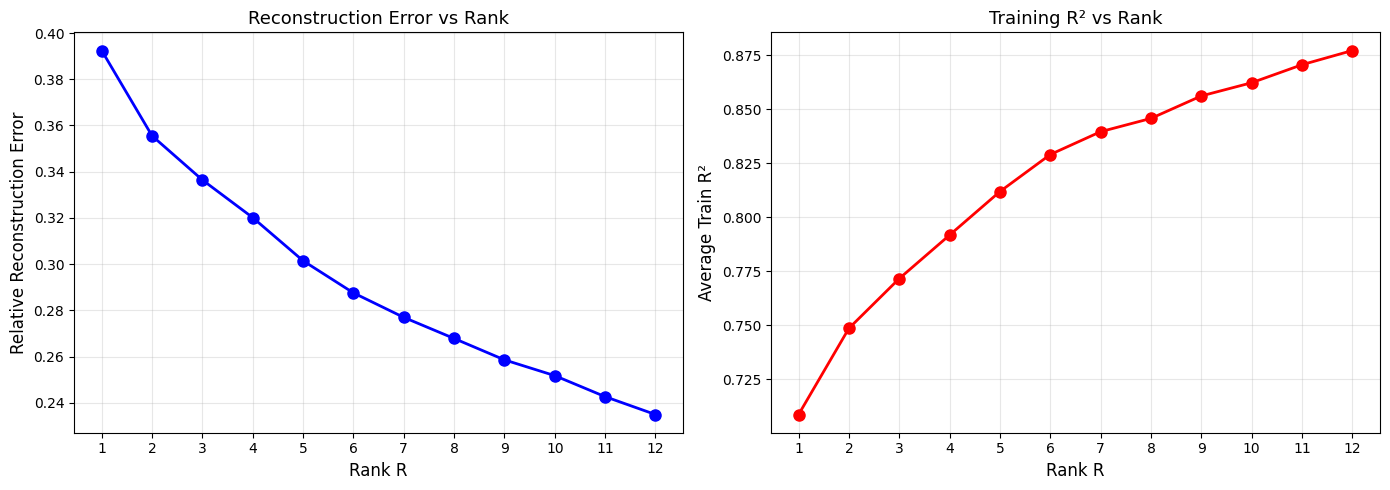


Suggested rank (elbow): 3
Max rank (before over-parameterization): 12


In [68]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

valid_ranks = [r for r, e in zip(ranks, reconstruction_errors) if not np.isnan(e)]
valid_errors = [e for e in reconstruction_errors if not np.isnan(e)]
valid_r2 = [r for r in train_r2_scores if not np.isnan(r)]

ax1.plot(valid_ranks, valid_errors, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Rank R', fontsize=12)
ax1.set_ylabel('Relative Reconstruction Error', fontsize=12)
ax1.set_title('Reconstruction Error vs Rank', fontsize=13)
ax1.grid(True, alpha=0.3)
ax1.set_xticks(valid_ranks)

ax2.plot(valid_ranks, valid_r2, 'ro-', linewidth=2, markersize=8)
ax2.set_xlabel('Rank R', fontsize=12)
ax2.set_ylabel('Average Train R\u00b2', fontsize=12)
ax2.set_title('Training R\u00b2 vs Rank', fontsize=13)
ax2.grid(True, alpha=0.3)
ax2.set_xticks(valid_ranks)

plt.tight_layout()
plt.show()

# Find elbow point
if len(valid_errors) >= 3:
    error_diffs = np.diff(valid_errors)
    error_diffs2 = np.diff(error_diffs)
    elbow_rank = valid_ranks[np.argmax(error_diffs2) + 2]
else:
    elbow_rank = 2
print(f"\nSuggested rank (elbow): {elbow_rank}")
print(f"Max rank (before over-parameterization): {max_rank}")

## 3. Forecasting Across Ranks

For each rank, decompose → forecast → measure test R². This shows how decomposition quality affects forecasting.

In [69]:
def forecast_with_rank(train_tensor, test_tensor, R, ar_lags=1):
    """Decompose, forecast year factors, reconstruct forecast tensor."""
    weights, factors = parafac(train_tensor, rank=R, normalize_factors=True)
    year_factors, month_factors, station_factors = factors
    
    # Forecast year factors using AutoReg
    forecast_year_factors = np.zeros((TEST_YEARS, R))
    for r in range(R):
        series = year_factors[:, r]
        model = AutoReg(series, lags=ar_lags, old_names=False)
        model_fit = model.fit()
        forecast = model_fit.forecast(steps=TEST_YEARS)
        forecast_year_factors[:, r] = forecast
    
    # Reconstruct forecast tensor
    forecast_tensor = np.zeros((TEST_YEARS, TIME, FEATURES))
    for i in range(TEST_YEARS):
        for r in range(R):
            forecast_tensor[i, :, :] += weights[r] * np.outer(
                forecast_year_factors[i, r] * month_factors[:, r], 
                station_factors[:, r]
            )
    
    return forecast_tensor

In [70]:
test_r2_by_rank = []
test_rmse_by_rank = []

for R in ranks:
    try:
        forecast_tensor = forecast_with_rank(train_tensor, test_tensor, R)
        
        test_series = test_tensor.reshape(-1, FEATURES)
        forecast_series = forecast_tensor.reshape(-1, FEATURES)
        
        r2_vals = []
        rmse_vals = []
        for f in range(FEATURES):
            r2_vals.append(r2_score(test_series[:, f], forecast_series[:, f]))
            rmse_vals.append(root_mean_squared_error(test_series[:, f], forecast_series[:, f]))
        
        test_r2_by_rank.append(np.mean(r2_vals))
        test_rmse_by_rank.append(np.mean(rmse_vals))
    except Exception as e:
        print(f"Rank {R} forecast failed: {e}")
        test_r2_by_rank.append(np.nan)
        test_rmse_by_rank.append(np.nan)

print("Rank | Test R\u00b2  | Test RMSE")
print("-" * 35)
for R, r2, rmse in zip(ranks, test_r2_by_rank, test_rmse_by_rank):
    print(f"  {R:2d}  |  {r2:.4f}  |  {rmse:.4f}")

valid_r2 = [(r, v) for r, v in zip(ranks, test_r2_by_rank) if not np.isnan(v)]
best_rank = max(valid_r2, key=lambda x: x[1])[0] if valid_r2 else 2
print(f"\nBest rank by test R\u00b2: {best_rank}")

Rank | Test R²  | Test RMSE
-----------------------------------
   1  |  0.7951  |  91.5663
   2  |  0.8074  |  88.2045
   3  |  0.8038  |  89.0697
   4  |  0.8170  |  85.4496
   5  |  0.8167  |  84.7573
   6  |  0.8152  |  84.5183
   7  |  0.8150  |  84.9900
   8  |  0.8164  |  83.7791
   9  |  0.8241  |  83.4961
  10  |  0.8288  |  82.3171
  11  |  0.8206  |  83.6895
  12  |  0.8311  |  82.8799

Best rank by test R²: 12


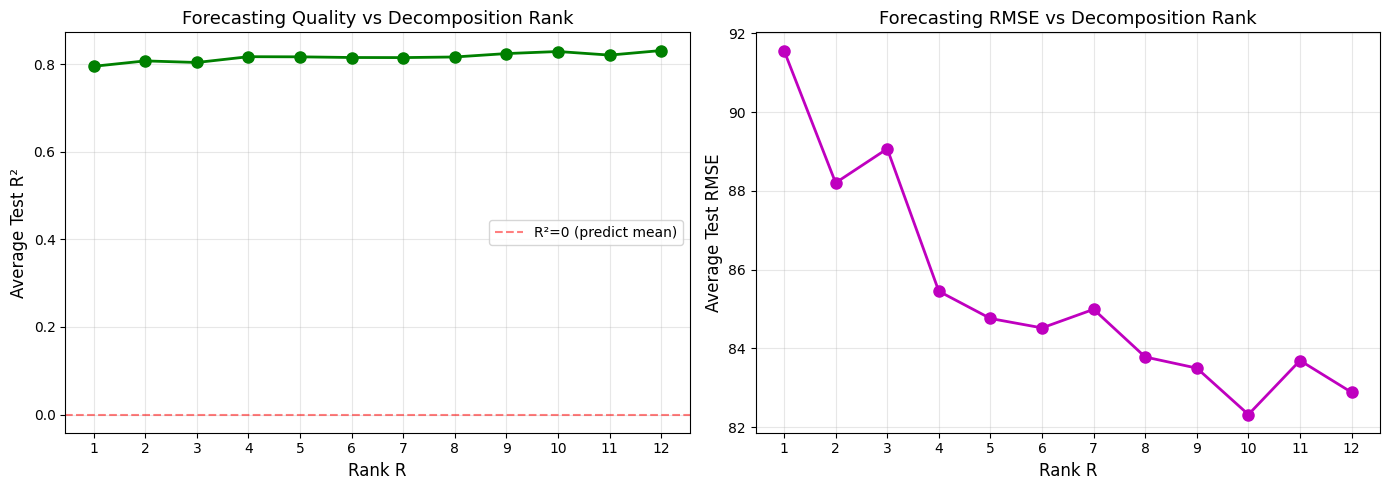

In [71]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

valid_ranks = [r for r, v in zip(ranks, test_r2_by_rank) if not np.isnan(v)]
valid_test_r2 = [v for v in test_r2_by_rank if not np.isnan(v)]
valid_test_rmse = [v for v in test_rmse_by_rank if not np.isnan(v)]

ax1.plot(valid_ranks, valid_test_r2, 'go-', linewidth=2, markersize=8)
ax1.set_xlabel('Rank R', fontsize=12)
ax1.set_ylabel('Average Test R\u00b2', fontsize=12)
ax1.set_title('Forecasting Quality vs Decomposition Rank', fontsize=13)
ax1.grid(True, alpha=0.3)
ax1.set_xticks(valid_ranks)
ax1.axhline(y=0, color='r', linestyle='--', alpha=0.5, label='R\u00b2=0 (predict mean)')
ax1.legend()

ax2.plot(valid_ranks, valid_test_rmse, 'mo-', linewidth=2, markersize=8)
ax2.set_xlabel('Rank R', fontsize=12)
ax2.set_ylabel('Average Test RMSE', fontsize=12)
ax2.set_title('Forecasting RMSE vs Decomposition Rank', fontsize=13)
ax2.grid(True, alpha=0.3)
ax2.set_xticks(valid_ranks)

plt.tight_layout()
plt.show()

## 4. Detailed Analysis with Best Rank

In [72]:
R = best_rank
print(f"Using rank R = {R}")

weights, factors = parafac(train_tensor, rank=R, normalize_factors=True)
year_factors, month_factors, station_factors = factors

reconstructed_tensor = cp_to_tensor((weights, factors))

rel_error = np.linalg.norm(train_tensor - reconstructed_tensor) / np.linalg.norm(train_tensor)
print(f"Relative reconstruction error: {rel_error:.6f}")

print("\nPer-station reconstruction R\u00b2:")
for f in range(FEATURES):
    r2 = r2_score(train_tensor[:, :, f].flatten(), reconstructed_tensor[:, :, f].flatten())
    print(f"  {feature_names[f]}: R\u00b2 = {r2:.6f}")

Using rank R = 12
Relative reconstruction error: 0.234981

Per-station reconstruction R²:
  Barisal: R² = 0.900166
  CoxsBazar: R² = 0.937721
  Ishurdi: R² = 0.828827
  Faridpur: R² = 0.842339
  Satkhira: R² = 0.846881
  Rangamati: R² = 0.885779
  Mymensingh: R² = 0.851333
  Dhaka: R² = 0.862077
  Khulna: R² = 0.847771
  Rangpur: R² = 0.857613
  Sylhet: R² = 0.894737
  Rajshahi: R² = 0.811910
  Srimangal: R² = 0.809673
  Bhola: R² = 0.850737
  Comilla: R² = 0.867158
  Bogra: R² = 0.840301
  Sandwip: R² = 0.927318
  M.court: R² = 0.932139
  Jessore: R² = 0.846843
  Chandpur: R² = 0.855859
  Feni: R² = 0.919128
  Khepupara: R² = 0.911545
  Chittagong: R² = 0.907769
  Patuakhali: R² = 0.900234
  Hatiya: R² = 0.930997
  Sitakunda: R² = 0.896710
  Teknaf: R² = 0.959783
  Dinajpur: R² = 0.828015
  Madaripur: R² = 0.885569


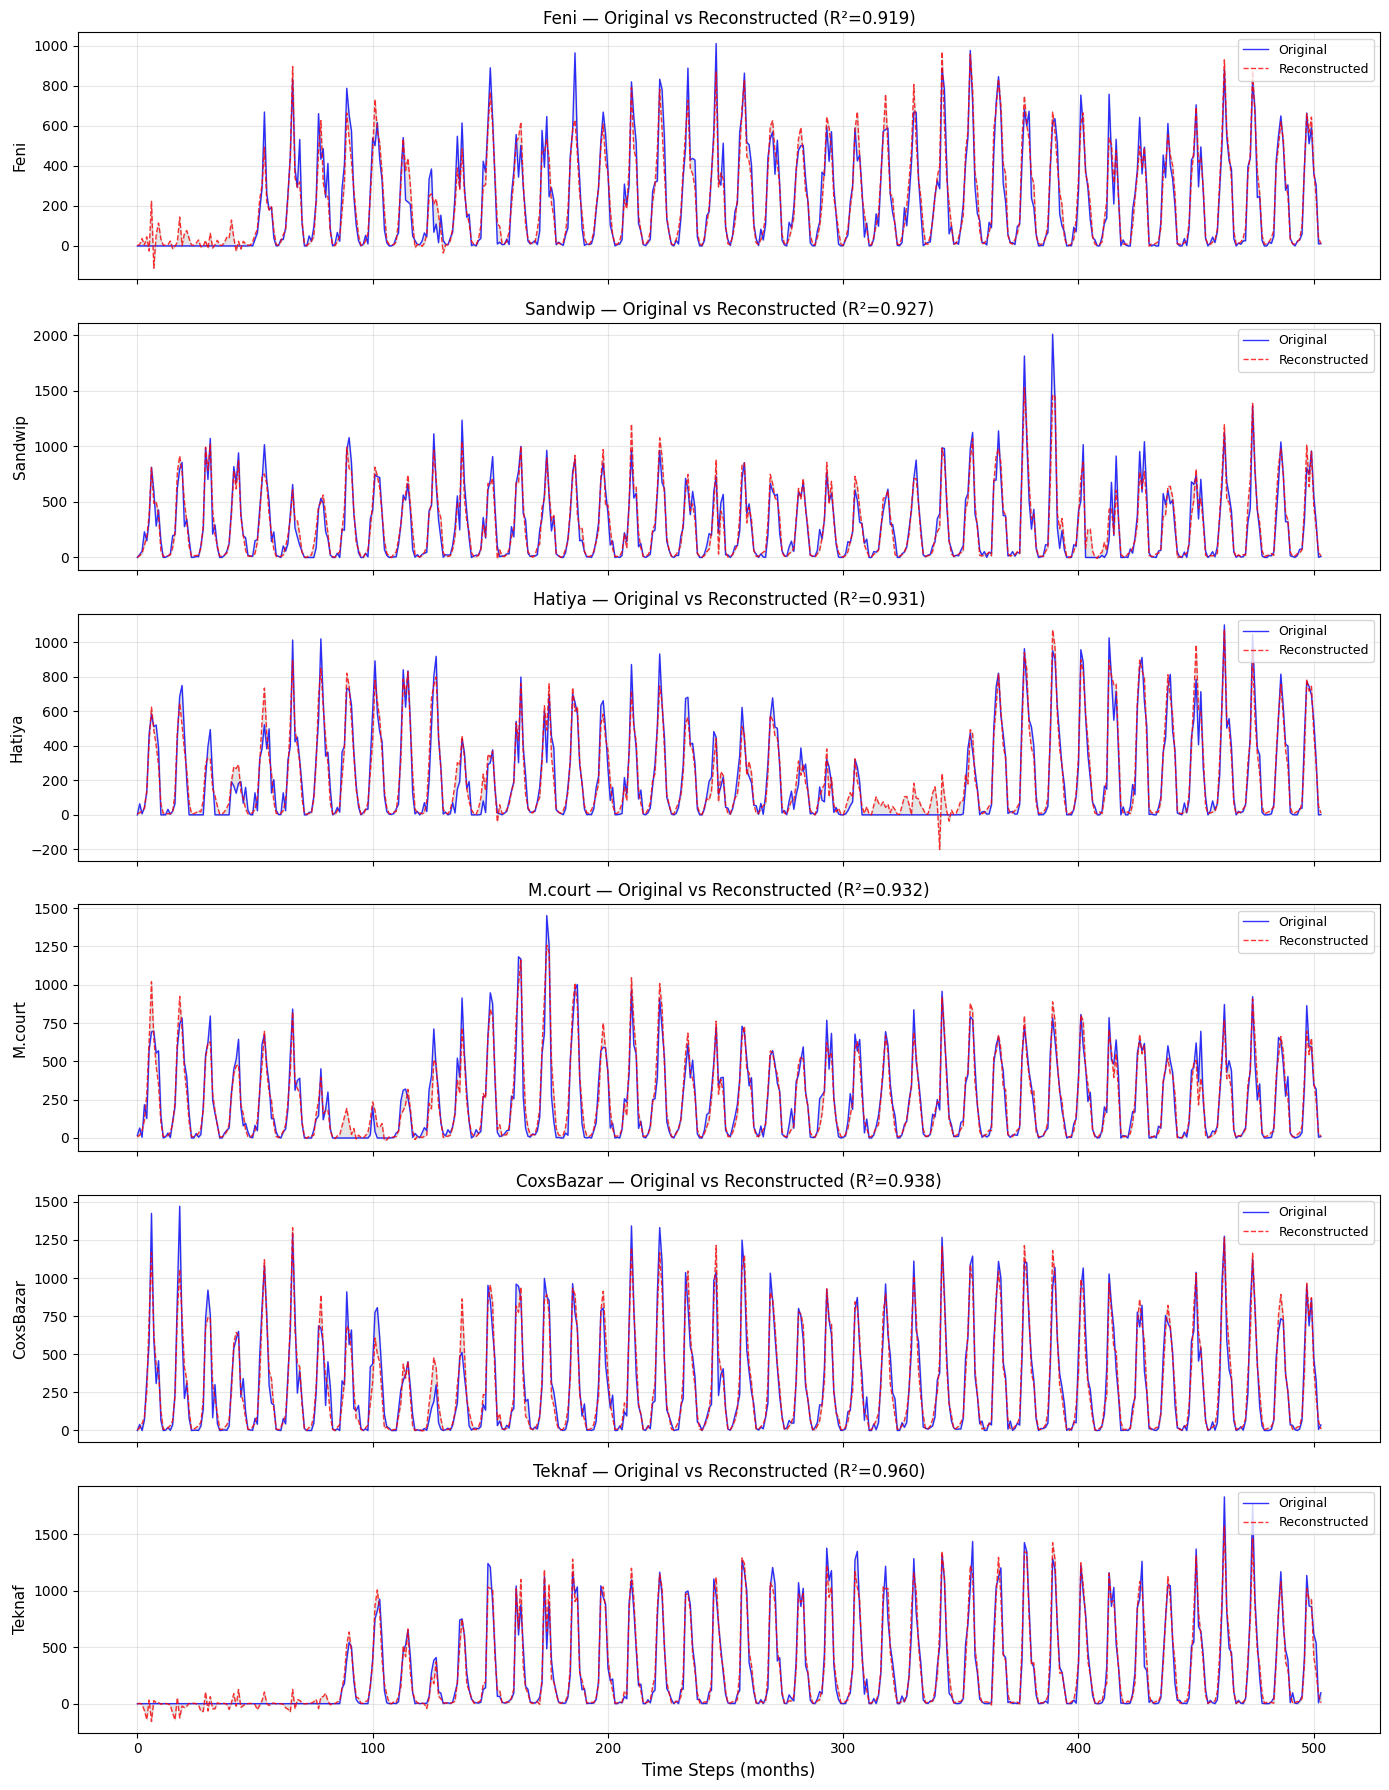

In [73]:
# Visualize reconstruction quality for a few representative stations
top_stations_idx = np.argsort([np.corrcoef(
    train_tensor[:, :, f].flatten(),
    reconstructed_tensor[:, :, f].flatten()
)[0, 1] for f in range(FEATURES)])[-6:]

fig, axes = plt.subplots(len(top_stations_idx), 1, figsize=(14, 3 * len(top_stations_idx)), sharex=True)
if len(top_stations_idx) == 1:
    axes = [axes]

for idx, f in enumerate(top_stations_idx):
    ax = axes[idx]
    original = train_tensor[:, :, f].flatten()
    recon = reconstructed_tensor[:, :, f].flatten()
    
    ax.plot(original, 'b-', lw=1, label='Original', alpha=0.8)
    ax.plot(recon, 'r--', lw=1, label='Reconstructed', alpha=0.8)
    ax.fill_between(range(len(original)), original, recon, alpha=0.2, color='gray')
    ax.set_ylabel(f'{feature_names[f]}', fontsize=11)
    r2 = r2_score(original, recon)
    ax.set_title(f'{feature_names[f]} — Original vs Reconstructed (R\u00b2={r2:.3f})', fontsize=12)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.xlabel('Time Steps (months)', fontsize=12)
plt.tight_layout()
plt.show()

## 5. Final Forecast with Best Rank

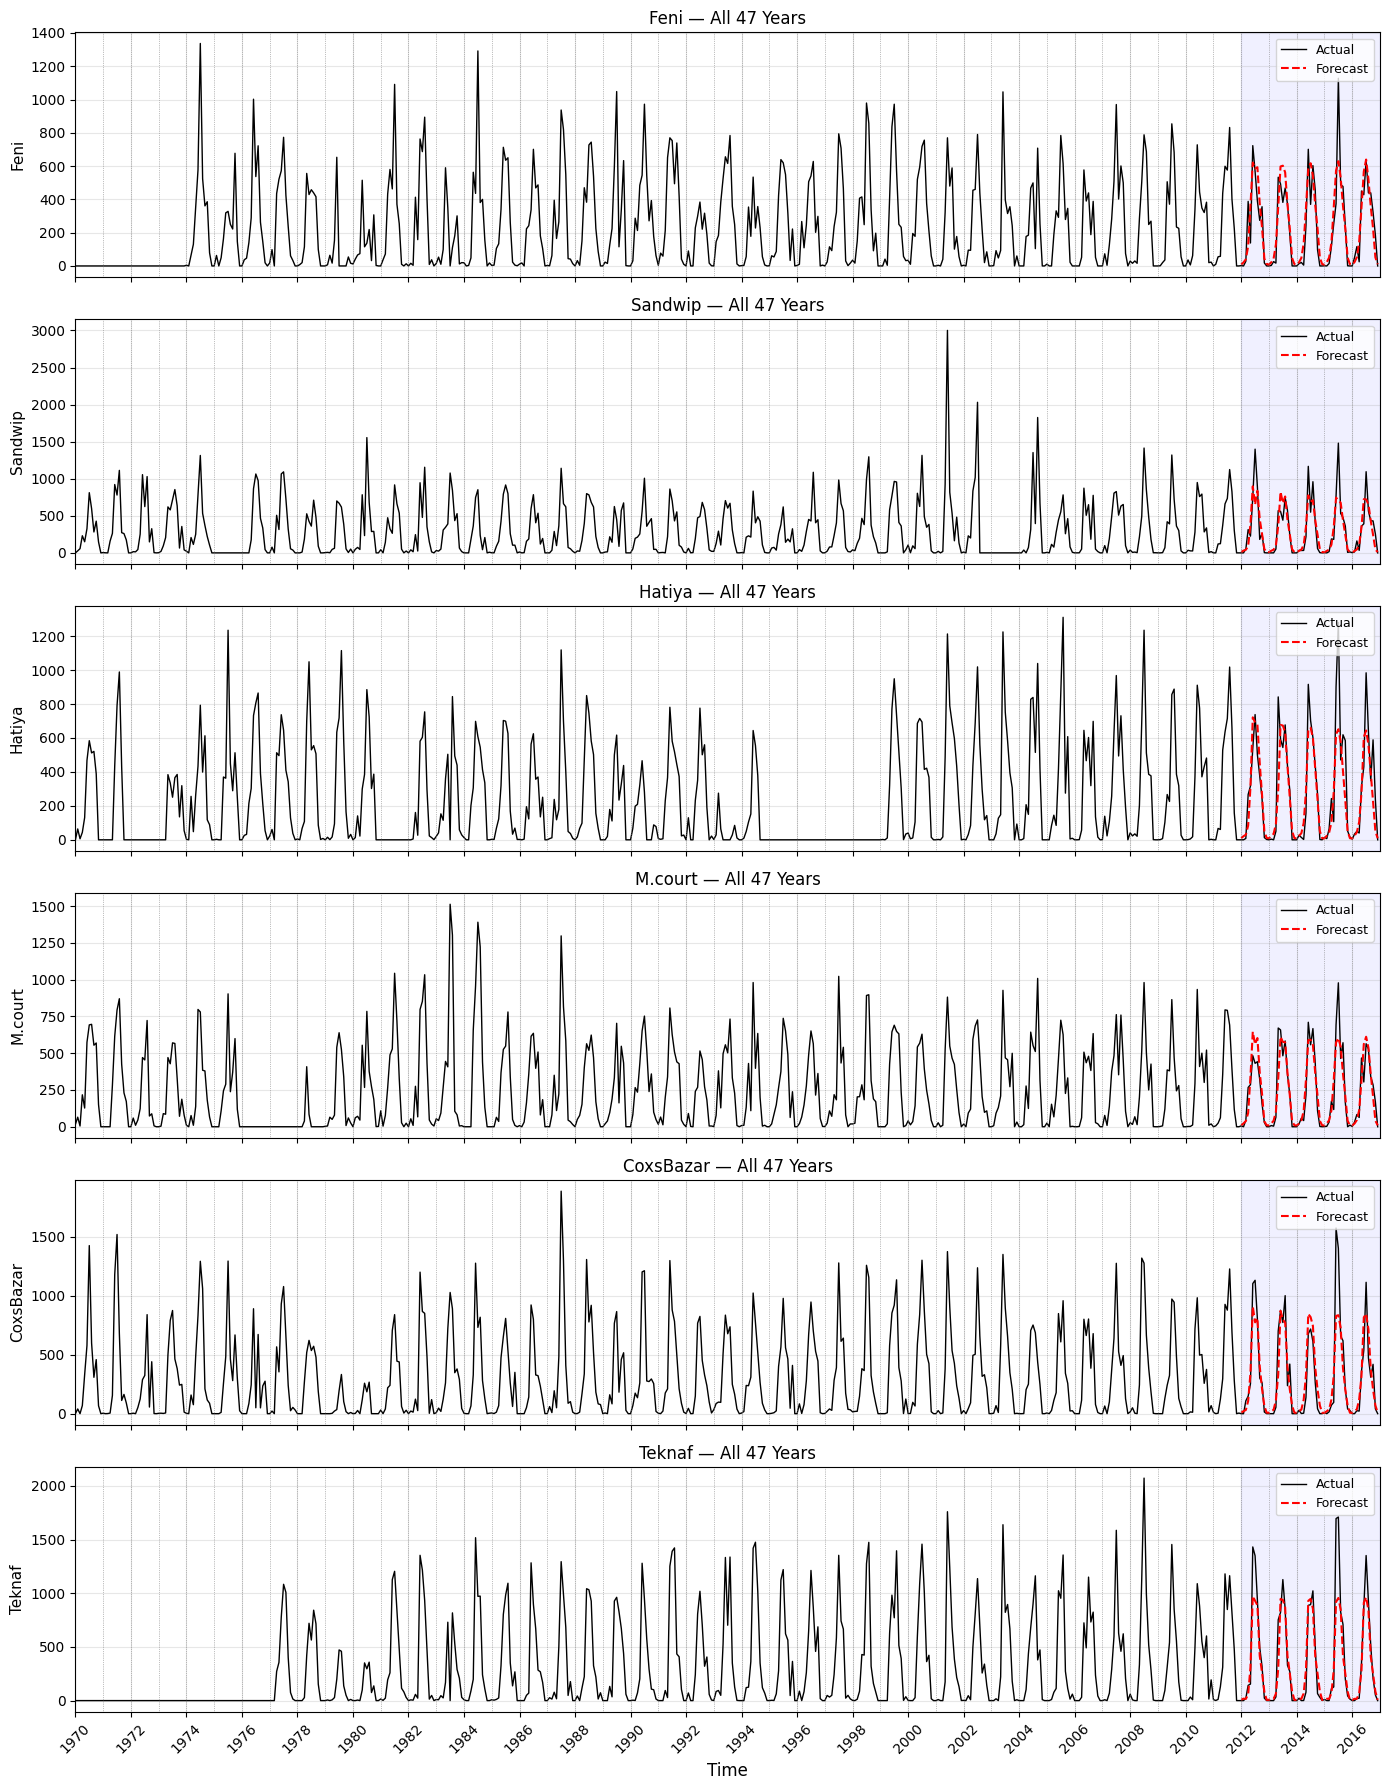

In [74]:
forecast_tensor = forecast_with_rank(train_tensor, test_tensor, R)

# Visualization: full series for a subset of stations
plot_stations = top_stations_idx  # reuse the top stations from reconstruction viz
n_plot = len(plot_stations)

fig, axes = plt.subplots(n_plot, 1, figsize=(14, 3 * n_plot), sharex=True)
if n_plot == 1:
    axes = [axes]

full_series = tensor.reshape(-1, FEATURES)
T = PERIOD * TIME
x = np.arange(T)
forecast_start = TRAIN_YEARS * TIME
x_forecast = np.arange(forecast_start, forecast_start + TEST_YEARS * TIME)

for idx, i in enumerate(plot_stations):
    ax = axes[idx]
    ax.plot(x, full_series[:, i], 'k-', lw=1, label='Actual')
    ax.plot(x_forecast, forecast_tensor.reshape(-1, FEATURES)[:, i], 'r--', lw=1.5, label='Forecast')
    for d in range(1, PERIOD + 1):
        ax.axvline(d * TIME, color='gray', ls=':', lw=0.5)
    ax.axvspan(forecast_start, T, alpha=0.06, color='blue')
    ax.set_ylabel(f'{feature_names[i]}', fontsize=11)
    ax.set_title(f'{feature_names[i]} — All {PERIOD} Years', fontsize=12)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)

full_tick_positions = np.arange(0, T + 1, 2 * TIME)
full_tick_labels = [str(years[min(y, PERIOD - 1)]) for y in range(0, PERIOD + 1, 2)]
plt.xticks(full_tick_positions, full_tick_labels, rotation=45)
plt.xlim(0, T)
plt.xlabel('Time', fontsize=12)
plt.tight_layout()
plt.show()

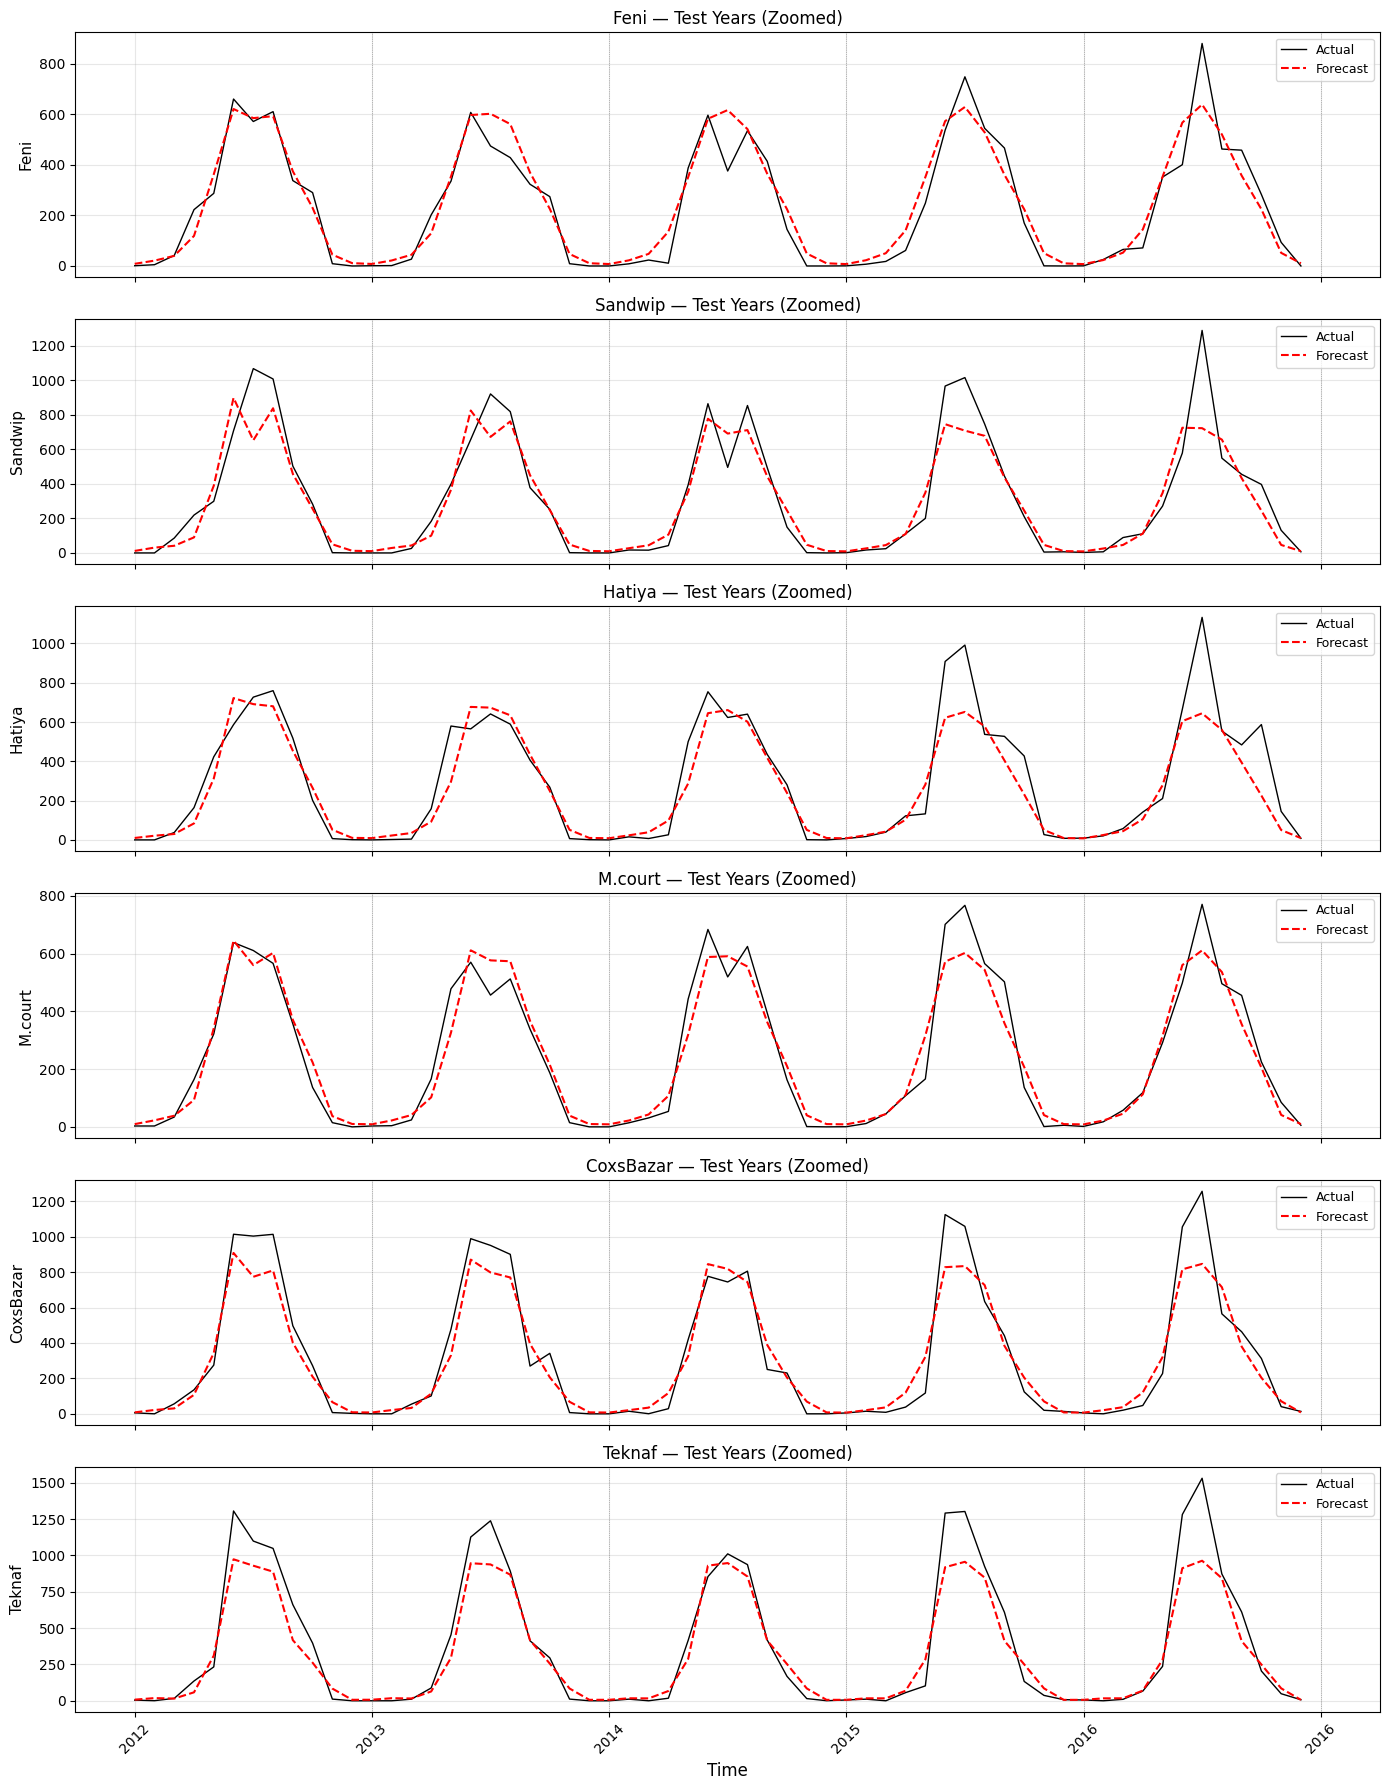

In [75]:
# Zoomed view: test years only
test_series = test_tensor.reshape(-1, FEATURES)
forecast_series = forecast_tensor.reshape(-1, FEATURES)
x = np.arange(TEST_YEARS * TIME)

fig, axes = plt.subplots(n_plot, 1, figsize=(14, 3 * n_plot), sharex=True)
if n_plot == 1:
    axes = [axes]

for idx, i in enumerate(plot_stations):
    ax = axes[idx]
    ax.plot(x, test_series[:, i], 'k-', lw=1, label='Actual')
    ax.plot(x, forecast_series[:, i], 'r--', lw=1.5, label='Forecast')
    for d in range(1, TEST_YEARS + 1):
        ax.axvline(d * TIME, color='gray', ls=':', lw=0.5)
    ax.set_ylabel(f'{feature_names[i]}', fontsize=11)
    ax.set_title(f'{feature_names[i]} — Test Years (Zoomed)', fontsize=12)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)

tick_positions = np.arange(0, TEST_YEARS * TIME + 1, TIME)
tick_labels = [str(years[min(TRAIN_YEARS + d, PERIOD - 1)]) for d in range(len(tick_positions))]
plt.xticks(tick_positions, tick_labels, rotation=45)
plt.xlabel('Time', fontsize=12)
plt.tight_layout()
plt.show()

## 6. Final Evaluation Metrics

In [76]:
print(f"Final model: Rank R = {R}")
print(f"Relative reconstruction error: {rel_error:.6f}")
print()

r2_scores = []
mse_scores = []
mae_scores = []
rmse_scores = []

# Show per-station metrics for top stations
print(f"{'Station':20s} | R\u00b2     | RMSE    | MAE")
print("-" * 55)
for i in plot_stations:
    r2 = r2_score(test_series[:, i], forecast_series[:, i])
    mse = mean_squared_error(test_series[:, i], forecast_series[:, i])
    mae = mean_absolute_error(test_series[:, i], forecast_series[:, i])
    rmse = root_mean_squared_error(test_series[:, i], forecast_series[:, i])
    r2_scores.append(r2)
    mse_scores.append(mse)
    mae_scores.append(mae)
    rmse_scores.append(rmse)
    print(f"{feature_names[i]:20s} | {r2:.4f} | {rmse:.4f} | {mae:.4f}")

print()
print(f"Average (top {n_plot}):     R\u00b2={np.mean(r2_scores):.4f}, RMSE={np.mean(rmse_scores):.4f}, MAE={np.mean(mae_scores):.4f}")

# Also show average across ALL stations
all_r2 = [r2_score(test_series[:, f], forecast_series[:, f]) for f in range(FEATURES)]
all_rmse = [root_mean_squared_error(test_series[:, f], forecast_series[:, f]) for f in range(FEATURES)]
all_mae = [mean_absolute_error(test_series[:, f], forecast_series[:, f]) for f in range(FEATURES)]
print(f"Average (all {FEATURES}):  R\u00b2={np.mean(all_r2):.4f}, RMSE={np.mean(all_rmse):.4f}, MAE={np.mean(all_mae):.4f}")

Final model: Rank R = 12
Relative reconstruction error: 0.234981

Station              | R²     | RMSE    | MAE
-------------------------------------------------------
Feni                 | 0.9064 | 73.1491 | 50.5507
Sandwip              | 0.8593 | 131.1220 | 81.2119
Hatiya               | 0.8388 | 122.6929 | 73.5207
M.court              | 0.9333 | 64.3870 | 45.2486
CoxsBazar            | 0.9113 | 114.8441 | 81.4965
Teknaf               | 0.8987 | 148.3819 | 90.4406

Average (top 6):     R²=0.8913, RMSE=109.0962, MAE=70.4115
Average (all 29):  R²=0.8311, RMSE=82.8799, MAE=54.2201
